# Exercise 1. Word Embeddings 101
This exercise does not have an RQ. Instead, it is all about exploring how **static word embeddings** work! 

To recap, static word embeddings are numerical vector representations of words in an n-dimensional space:

```{figure} ../figures/class3/embeddings-allamar.png
---
name: embeddings
width: 80%
---
from {cite:t}`hands-on-llms-book` (Chapter 1)
```

:::{admonition} What are **static** and **dynamic** embeddings?
:class: tip, dropdown

**Static** embeddings represent each word with a single, fixed embedding vector. As you'll see in {ref}`Section 1.2 <12-exploring-polywords>`, this can give some issues as a lot of words have more than one meaning.

In contrast, **dynamic** (or *contextual*) embeddings assign vectors that change depending on the surrounding sentence or document. That is, the representation of a word adapts to the context it is in!
:::

## 1.1 Load a Pretrained Embedding Model
Start by installing the package `gensim`: 

In [3]:
%pip install gensim


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Let's import `pathlib` and `KeyedVectors` from `gensim.models` 

In [4]:
from pathlib import Path
from gensim.models import KeyedVectors

Load the `pre-installed` model `GloVe`

In [5]:
path = Path.cwd()
models_path = path.parents[1] / "resources" / "models" 

# note the str() as KeyedVectors.load() needs a string path !
model = KeyedVectors.load(str(models_path / "glove_wiki_gigaword_300.kv")) 

:::{admonition} What is GloVe? Can I use other models?
:class: tip, dropdown
`GloVe` word vectors are trained on aggregated global word-word co-occurrence statistics from a corpus. The `glove-wiki-gigaword-300` vectors are 300-dimensional and trained on co-occurence statistics from Wikipedia articles and various news outlets. See also {cite:t}`pennington_glove_2014`

You can download (other) models such as `FastText` as such: 
```python
import gensim.downloader as api
model = api.load("fasttext-wiki-news-subwords-300") 
```
See [Models](https://github.com/piskvorky/gensim-data?tab=readme-ov-file#models) for the model overview and read more about [gensim.downloader](https://radimrehurek.com/gensim/downloader.html).
:::


> Note: I have downloaded Word2Vec in our resources folder as well. Feel free to experiment with that!

(12-exploring-polywords)=
## 1.2 Exploring Polysemous Words
Polysemy refers to words that have two or more meanings. There are many out there:
```{figure} ../figures/class3/polysemy.png
---
name: polysemy
width: 80%
---
```

We can look at the most similar words (cosine similarity) for the word `leaves` in our model to illustrate this:

In [6]:
model.most_similar("leaves", topn=15)

[('leaf', 0.5564894080162048),
 ('stems', 0.554435670375824),
 ('leaving', 0.5414506196975708),
 ('leave', 0.5339293479919434),
 ('ends', 0.526331901550293),
 ('flowers', 0.48853448033332825),
 ('stalks', 0.47854116559028625),
 ('grows', 0.47765129804611206),
 ('arrives', 0.47416287660598755),
 ('takes', 0.47301051020622253),
 ('foliage', 0.4626350700855255),
 ('turns', 0.4491370916366577),
 ('goes', 0.44434431195259094),
 ('becomes', 0.43927299976348877),
 ('comes', 0.43823492527008057)]

:::{admonition} Question
:class: red
Take a look at the words above - what do you notice? Speak with a friend about it!
:::


### Your Turn: Try it out!
:::{admonition} HANDS-ON
:class: red
As a starting exercise, find a polysemous word like `leaves` or `bat` whose top-15 most similar words (by cosine similarity) reflect multiple meanings.
- Remember to use `model.most_similar()` and write words in *lowercase*.
- If stuck, try to Google "polysemous words" for inspiration!

**Please share** your example on [TaskCards](https://aarhusuni.taskcards.app/#/board/348eeb06-6344-4e0b-b78c-7f6e4019ed98?token=8e393c0f-4d21-4dbc-9f98-c192309ca4e0) (ask me for password or see on BrightSpace).
:::


## 1.3 Synonyms and Antonyms

Let's explore synonyms and antonyms with word embeddings. One approach is *cosine distance*, defined as `1 - cosine similarity`. 

The higher the distance, the farther apart two words are in vector space. This means that they should have less "in common", but word embeddings are not always intuitive!

For example, an antonym for the word `"happy"` is the word `"sad"`:

In [7]:
model.distance("happy", "sad")

0.43471431732177734

And a synonym for `happy` would be`cheerful`:

In [8]:
model.distance("happy","cheerful") # remember, the higher the distance, the less similar!

0.5596834421157837

Although `happy` and `cheerful` are synonyms, `happy` is actually closer to `sad` than to `cheerful` in terms of cosine distance! We can also check this programatically with the "less than" boolean operator `<`

In [9]:
# if true, happy is closer to sad than to cheerful
model.distance("happy", "sad") < model.distance("happy","cheerful") 

True

:::{admonition} QUESTION
:class: red
With your knowledge about *embeddings*, can you explain why *happy* is closer to *sad* than *cheerful*?
:::

### Your Turn: Finding Counter-Intutive Synonym-Antonym pairs!
:::{admonition} HANDS-ON & QUESTION
:class: red

**TASK 1**

Find three words (`w1`,`w2`,`w3`) where `w1` and `w2` are synonyms and `w1` and `w3` are antonyms, but where `w1` is closer to its antonym `w3` than to its synonym `w2`:

`Cosine Distance(w1,w3) < Cosine Distance(w1,w2)`

This is just what we did above!

**TASK 2**

Can you explain why your *counter-intuitive* example happens (with your knowledge about embeddings) ? 

**TASK 3**

**Share** your example and considerations on [TaskCards](https://aarhusuni.taskcards.app/#/board/348eeb06-6344-4e0b-b78c-7f6e4019ed98?token=8e393c0f-4d21-4dbc-9f98-c192309ca4e0).
:::


## 1.4 Exploring Word Analogies
An interesting feature of trained word embeddings is that we can discover *analogies* by doing basic arithmetic (addition/subtraction). That is, the embedding for *queen* can be approximated as:

$$
\mathbf{w}_{\text{queen}} \approx \mathbf{w}_{\text{king}} - \mathbf{w}_{\text{man}} + \mathbf{w}_{\text{woman}}
$$

Corresponding to the statement "**man** is to **king** as **woman** is to **queen**" (I recommend reading {cite:t}`allen_analogies_2019` for deeper insights).


In Python, we do this arithmetic with the method `most_similar()` using this (weird) syntax:

In [ ]:
model.most_similar(positive=['king', 'woman'], 
                   negative=['man'])[0] # 0 to get only the closest word

('queen', 0.6713277101516724)

> NB: Depending on the model, it might not be exactly the vector for queen, but could be e.g., "princess" or "monarch" :)

### Your Turn: "Correct" & "Wrong" Analogies
Please do this task with a classmate or two! Experiment and discuss!

:::{admonition} HANDS-ON
:class: red

Use the `.most_similar()` function on your model and do the following tasks:

**TASK A**  
Find "correct" analogies. By "correct," I mean analogies where the closest vector corresponds to the word you expect (like the king–queen example). You should:  
1. Try to find *at least two* analogies.

**TASK B**  
Find "wrong" analogies. By "wrong," I mean analogies that *should* work (like the king–queen example) but *do not*. You should:  
1. Try to find *at least one* where the closest vector does not correspond to what you expect!
2. Consider why your analogies may not work!

**TASK C**   
Share your best analogy (correct or wrong) on [TaskCards](https://aarhusuni.taskcards.app/#/board/348eeb06-6344-4e0b-b78c-7f6e4019ed98?token=8e393c0f-4d21-4dbc-9f98-c192309ca4e0). Remember to provide a short explanation!
:::

My solution

In [ ]:
# analogies that hold! 
print("[INFO:] Analogies that hold!")
print(model.most_similar(positive=["god", "woman"], 
                    negative=["man"])[0]) # god - man + woman = goddess

print(model.most_similar(positive=["paris", "italy"],
                        negative=["france"])[0]) # paris - france + italy = rome

print(model.most_similar(positive=["psychology", "humanities"],
                          negative=["statistics"])[0]) # psychology - statistics + humanities = anthropology

print(model.most_similar(positive=["comedy", "romantic"], negative=["funny"])[0]) # comedy - funny + romantic = drama

# print space between the two sections
print("\n")

# analogy that does not hold
print("[INFO:] Analogies that should hold, but do not!")
print(model.most_similar(positive=["ship", "road"], negative=["ocean"])[0]) # ship - ocean + road = "roads" (does also not work if you replace road with wheels)
print(model.most_similar(positive=["trousers", "hot"], negative=["long"])[0]) # trousers - long + hot = "shorts" (does not work?)

[INFO:] Analogies that hold!
('goddess', 0.5733169317245483)
('rome', 0.7368948459625244)
('anthropology', 0.6434165835380554)
('drama', 0.6114351153373718)


[INFO:] Analogies that should hold, but do not!
('roads', 0.45349568128585815)
('pants', 0.57420814037323)


## 1.5 Uncovering Bias
Due to the way embeddings are trained, they may contain some biases. While basic heuristics are fine, gender stereotypes can be problematic when applying these embeddings in the real world!

Let's try: 
`director - man + woman`

In [12]:
print(model.most_similar(positive=["director", "woman"],
                          negative=['man']))

[('assistant', 0.4793030619621277), ('chairwoman', 0.4766245186328888), ('executive', 0.46431592106819153), ('susan', 0.4622037410736084), ('spokeswoman', 0.45612895488739014), ('associate', 0.4546034634113312), ('directors', 0.44585469365119934), ('actress', 0.4415530860424042), ('deputy', 0.42916229367256165), ('researcher', 0.41419851779937744)]


### Your Turn: Explore Bias in Embeddings
:::{admonition} HANDS-ON
:class: red

Using some of the techniques you've worked on above, find at least one clear instance of bias in word embeddings.

**Please share** your example on [TaskCards](https://aarhusuni.taskcards.app/#/board/348eeb06-6344-4e0b-b78c-7f6e4019ed98?token=8e393c0f-4d21-4dbc-9f98-c192309ca4e0).
:::

## 1.6 Visualization
So far, we have looked at how words relate to each other with cosine scores. To get a better overview, we can also visualize these relationships!

### Dimensionality reduction
Since embeddings usually have many more than 2 or 3 dimensions, we need to reduce their dimensionality in order to visualize them:
```{figure} ../figures/class3/dim_reduction.png
---
name: dim-reduction
---
From [Gautam (2020, Medium)](https://medium.com/@hari4om/word-embedding-d816f643140)
```

Various dimensionality reduction algorithms exist. Two useful ones for our case is [Singular Value Decomposition (SVD)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) and [Principal Component Analysis (PCA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). 

Start by installing `scikit-learn`: 

In [13]:
%pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Let's import PCA & TSNE (we only need one now, but we'll want to compare later!)

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Choose a few words that we want to plot and extract embeddings from them:

In [15]:
# word we want to plot
words = ["man", "woman", "doctor", "nurse", "king", "queen", "boy", "girl"]

# an empty list for embeddings
embeddings = []

# get vectors for subset of words
for word in words:
    embeddings.append(model[word]) # get the embedding vector for each word using our MODEL

We can now apply the PCA alg. to our `embeddings` for the chosen words. We write  `n_components = 2` to reduce dimensions to 2D:

In [23]:
pca = PCA(n_components=2, random_state=42) # instantiate PCA object
embeddings_pc = pca.fit_transform(embeddings)

:::{admonition} QUESTION
:class: red
Can you remember where you have seen this sort of workflow with instantiating an object that then can be used to `fit_transform` data ;)?
:::

### Plotting!
Now that we have reduced the dimensions of our embddings, let's install and import`pandas`, `matplotlib` and `seaborn`:

In [17]:
%pip install matplotlib pandas seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
# best practice at top of notebook
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

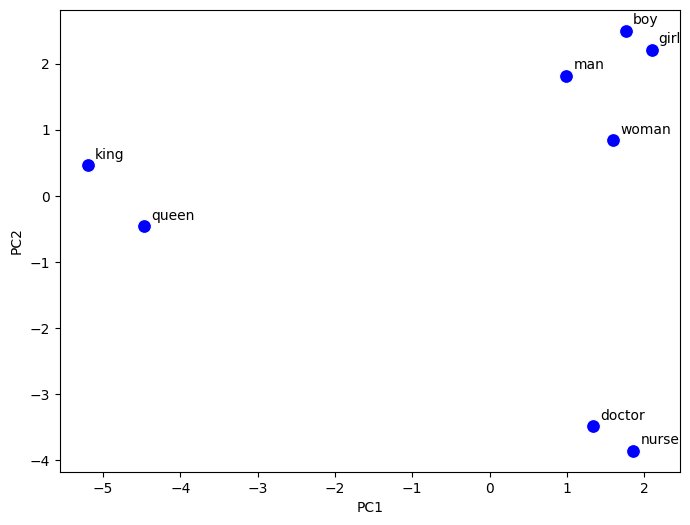

In [19]:
# convert to DF 
df = pd.DataFrame(embeddings_pc, columns=["PC1", "PC2"]) # common PCA dims PC1 and PC2
df["word"] = words

# create a scatter plot
plt.figure(figsize=(8, 6)) # width, height

sns.scatterplot(data=df, 
                x="PC1", # first dim on x
                y="PC2", # second dim on y
                s=100, # size of points 
                color="blue", 
                )


# add words to points
for _, row in df.iterrows():
    plt.annotate(
        row["word"],                     # text to display
        (row["PC1"], row["PC2"]),        # coordinates of the point being labeled
        xytext=(5, 5),                   # offset of the text from the point (in points)
        textcoords="offset points",      # interpret xytext in points relative to the point
        fontsize=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Your Turn: Reduce Dims & Plot on your Own Words!
:::{admonition} HANDS-ON
:class: red
Do you have any words that could be interesting to plot and explore? Your task is:
1. Define your *own* list of words. Select a few more than 8!
2. Extract `embeddings` using a `for loop` (use my code for this!)
3. Transform the `embeddings` using both `PCA` and `TSNE`
    - For `TSNE` (see also hints below)
        1. You need to convert `embeddings` to a `numpy array` before using `TSNE`
        2. You need to set `perplexity = 5` (you can experiment with the exact integer, but it has to be below the amount of words, see [docs](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)) 
4. Plot both versions using the code snippet above.
5. **Please share** your words and either the `PCA` or `TSNE` plot on [TaskCards](https://aarhusuni.taskcards.app/#/board/348eeb06-6344-4e0b-b78c-7f6e4019ed98?token=8e393c0f-4d21-4dbc-9f98-c192309ca4e0)

For an extra challenge, you can try to 1) make relevant functions for this pipeline and 2) make the plot prettier!
:::

:::{admonition} HINT. Converting to `numpy array`
:class: tip, dropdown
Before using `TSNE`, you need to convert your list of embeddings into a `numpy array` first:
```python
%pip install numpy
import numpy as np

embeddings = np.array(embeddings)
```
:::

:::{admonition} HINT. How to use TSNE? 
:class: tip, dropdown
TSNE is very similar to PCA, but requires you to set a `perplexity` (and convert your `embeddings` list to `np.array`)
```python
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_tsne = tsne.fit_transform(embeddings)
```
:::

#### Solution

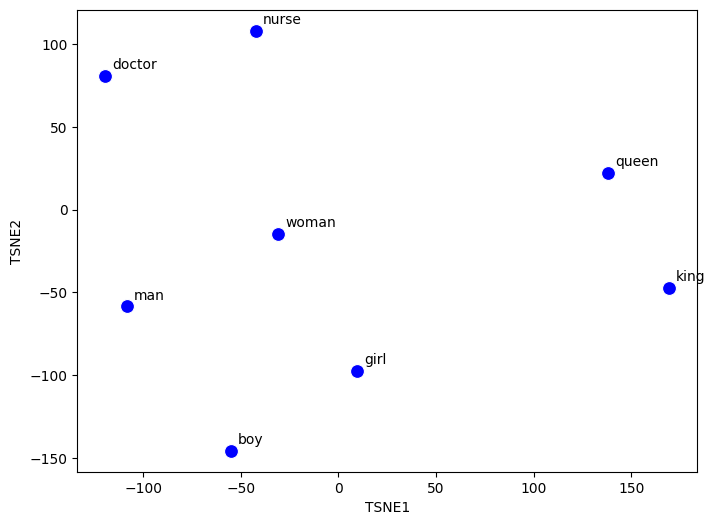

In [36]:
# install and import numpy if you haven't already
# %pip install numpy
import numpy as np


tsne = TSNE(n_components=2, random_state=42, perplexity=5) # instantiate TSNE object
embeddings_tsne = tsne.fit_transform(np.array(embeddings))

# convert to DF 
df = pd.DataFrame(embeddings_tsne, columns=["TSNE1", "TSNE2"]) 
df["word"] = words

# create a scatter plot
plt.figure(figsize=(8, 6)) # width, height

sns.scatterplot(data=df, 
                x="TSNE1", # first dim on x
                y="TSNE2", # second dim on y
                s=100, # size of points 
                color="blue", 
                )


# add words to points
for _, row in df.iterrows():
    plt.annotate(
        row["word"],                     # text to display
        (row["TSNE1"], row["TSNE2"]),        # coordinates of the point being labeled
        xytext=(5, 5),                   # offset of the text from the point (in points)
        textcoords='offset points',      # interpret xytext in points relative to the point
        fontsize=10
    )

plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

### PCA versus TSNE?
Now that you have made your plots, consider the questions below ...
:::{admonition} QUESTION
:class: red

Consider these two questions with a friend and write a few bullets down!
1. Do you notice any interesting relations between your words? Which
2. How do your results change depending on the reductionality method?
:::

:::{admonition} Curious how PCA and TSNE works? 
:class: tip

Outside of class, I recommend watching this video:
<iframe width="560" height="315" src="https://www.youtube.com/embed/o_cAOa5fMhE?si=TC2fT29rFUEO0nS_" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>
:::
